In [2]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data2,grid_cell,adaptive_int,visual,cal_S_grad,org_m,mea_2D,net_2D_fix2,S_valgrad,error_general_ada,main,draw,gridlook
CUDA_LAUNCH_BLOCKING=1

def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values

cuda:0


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/_environment.py:541: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


In [3]:
import pickle
S_num_proce=np.load("./Noise/noise=10%/S_num_1600*2_10-30.npy")
with open("./Noise/noise=10%/cells_store_last.pkl", "rb") as f:
    cells_store=pickle.load(f)
x = np.linspace(0, 1, 301)
y = np.linspace(0, 1, 301)
X, Y = np.meshgrid(x, y,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel())).T
tau_x_min=0.0
tau_x_max=1.0
tau_y_min=0.0   
tau_y_max=1.0
# # 创建数据
# S_num_store=np.load("./results_ada/noise=5%_refine/S_num_store.npy")

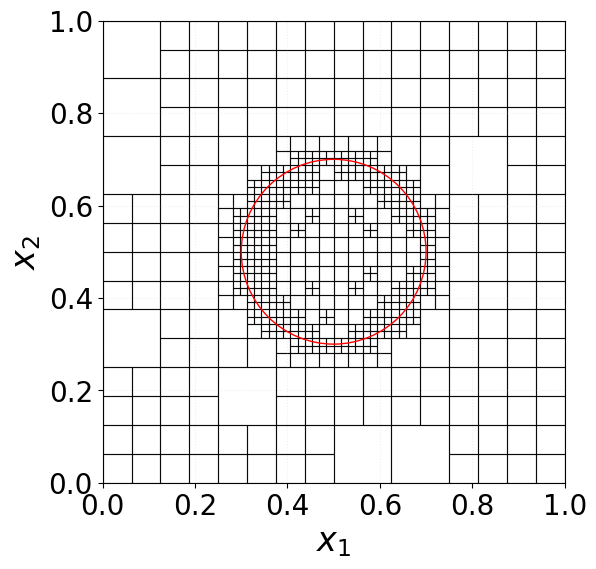

In [4]:
import gridlook
reload(gridlook)
import matplotlib.pyplot as plt
v=gridlook.MeshVisualizer()
fig, axes = plt.subplots(1, 1, figsize=(6, 6))  # 每个阶段画一个子图
fig=v._plot_single_mesh(fig,axes,cells_store, S_num=None, points=samples,label=True)

In [5]:
fig.savefig("./Noise/noise=10%/mesh.pdf", dpi=300, bbox_inches='tight')

In [6]:
S_exact= f_circle(samples,0,1,0,1,center=[0.5,0.5],r=0.2).reshape(301,301)

In [7]:
import Bound_detect
reload(Bound_detect)
g_S=np.load("./Noise/noise=10%/g_S.npy")
S_num_store=np.load("./Noise/noise=10%/S_num_store.npy")

Number of detected clusters: 1
Cluster 0: AR=1.00
  Res_Rect=0.097 vs Res_Ellip=0.021
  -> Winner: Circle
  CV of S_num: 0.265
Cluster 0: Lx=0.400, Ly=0.400, AR=1.00
  -> Decision: Circle (Sigmoid)
  Center: (0.496, 0.502)
    Radius: 0.204
    Rect Residual: 0.0970, Ellip Residual: 0.0214
    Aspect Ratio: 1.000
    Curvature - Std: 0.3939, Mean: 0.1706, Peak Ratio: 8.29


/data5/store1/hxw/code/Ex4.3/./main_code/Bound_detect.py:431: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


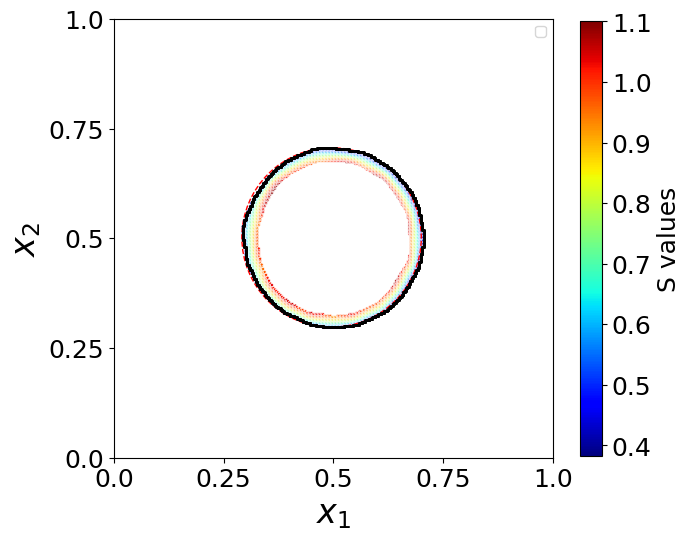

<Figure size 640x480 with 0 Axes>

In [10]:
from importlib import reload
reload(Bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=0.02
mini_samples=20
para_abs=3
para_grad=3
results=Bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs,para_grad,eps_cluster,mini_samples,S_num_store[-1],output_directory="./Noise/noise=10%/", output_filename="detect.pdf")

Plot saved as ./Noise/noise=10%/S_num.pdf


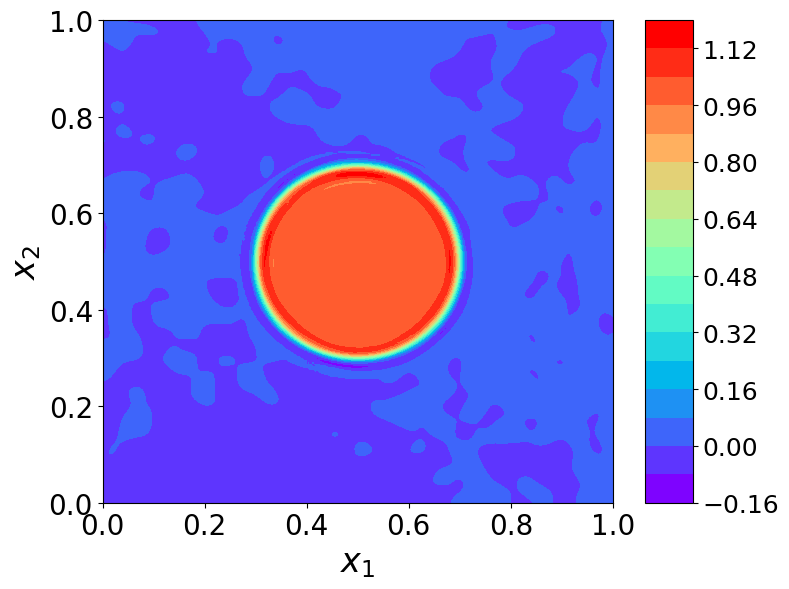

Plot saved as ./Noise/noise=10%/S_exact.pdf


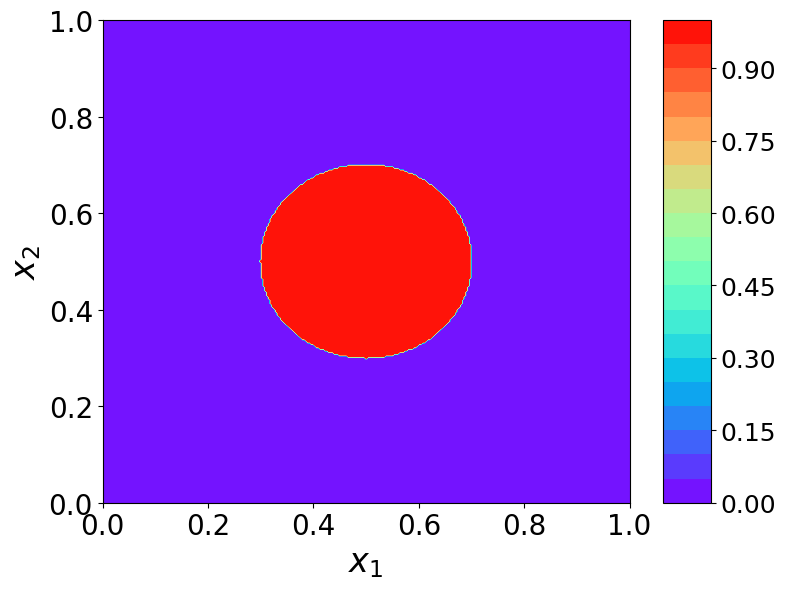

Plot saved as ./Noise/noise=10%/abs_S.pdf


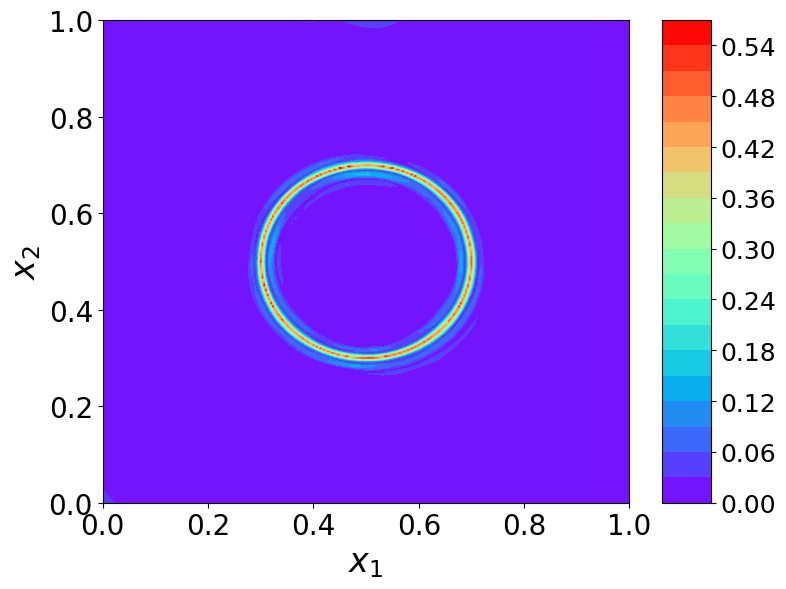

In [9]:
reload(draw)
draw.draw(X, Y, S_num_proce, output_directory="./Noise/noise=10%/", output_filename="S_num.pdf")
draw.draw(X, Y, S_exact, output_directory="./Noise/noise=10%/", output_filename="S_exact.pdf")
draw.draw(X, Y, np.abs(S_num_proce - S_exact), output_directory="./Noise/noise=10%/", output_filename="abs_S.pdf")